# Spectral fitting example (AGN)

**To run this, you need the following files, which can be downloaded using the first few cells of this notebook:**
- orientation file (20280301_3_month_with_orbital_info.ori)       
- binned data (NGC4151_ec200_bkg_binned_data.hdf5, NGC4151_ec200_binned_data.hdf5, & bkg_binned_data.hdf5)     
- detector response (SMEXv12.Continuum.HEALPixO3_10bins_log_flat.binnedimaging.imagingresponse.nonsparse_nside8.area.good_chunks_unzip.h5.zip)     

**The binned data are simulations of the NGC4151_ec200 Nebula and albedo photon background produced using the COSI SMEX mass model. The detector response needs to be unzipped before running the notebook.**

This notebook fits the spectrum of a NGC4151_ec200 simulated using MEGAlib and combined with background.

[3ML](https://threeml.readthedocs.io/) is a high-level interface that allows multiple datasets from different instruments to be used coherently to fit the parameters of source model. A source model typically consists of a list of sources with parametrized spectral shapes, sky locations and, for extended sources, shape. Polarization is also possible. A "coherent" analysis, in this context, means that the source model parameters are fitted using all available datasets simultanously, rather than performing individual fits and finding a well-suited common model a posteriori. 

In order for a dataset to be included in 3ML, each instrument needs to provide a "plugin". Each plugin is responsible for reading the data, convolving the source model (provided by 3ML) with the instrument response, and returning a likelihood. In our case, we'll compute a binned Poisson likelihood:

$$
\log \mathcal{L}(\mathbf{x}) = \sum_i \log \frac{\lambda_i(\mathbf{x})^{d_i} \exp (-\lambda_i)}{d_i!}
$$

where $d_i$ are the counts on each bin and $\lambda_i$ are the expected counts given a source model with parameters $\mathbf{x}$. 

In this example, we will fit a single point source with a known location. We'll assume the background is known and fixed up to a scaling factor. Finally, we will fit a Band function:

$$
f(x) = K \begin{cases} \left(\frac{x}{E_{piv}}\right)^{\alpha} \exp \left(-\frac{(2+\alpha)
       * x}{x_{p}}\right) & x \leq (\alpha-\beta) \frac{x_{p}}{(\alpha+2)} \\ \left(\frac{x}{E_{piv}}\right)^{\beta}
       * \exp (\beta-\alpha)\left[\frac{(\alpha-\beta) x_{p}}{E_{piv}(2+\alpha)}\right]^{\alpha-\beta}
       * &x>(\alpha-\beta) \frac{x_{p}}{(\alpha+2)} \end{cases}
$$

where $K$ (normalization), $\alpha$ & $\beta$ (spectral indeces), and $x_p$ (peak energy) are the free parameters, while $E_{piv}$ is the pivot energy which is fixed (and arbitrary).

Considering these assumptions:

$$
\lambda_i(\mathbf{x}) = B*b_i + s_i(\mathbf{x})
$$

where $B*b_i$ are the estimated counts due to background in each bin with $B$ the amplitude and $b_i$ the shape of the background, and $s_i$ are the corresponding expected counts from the source, the goal is then to find the values of $\mathbf{x} = [K, \alpha, \beta, x_p]$ and $B$ that maximize $\mathcal{L}$. These are the best estimations of the parameters.

The final module needs to also fit the time-dependent background, handle multiple point-like and extended sources, as well as all the spectral models supported by 3ML. Eventually, it will also fit the polarization angle. However, this simple example already contains all the necessary pieces to do a fit.

In [2]:
from cosipy import COSILike, test_data, BinnedData
from cosipy.spacecraftfile import SpacecraftFile
from cosipy.response.FullDetectorResponse import FullDetectorResponse
from cosipy.util import fetch_wasabi_file
from histpy import Histogram

from scoords import SpacecraftFrame

from astropy.time import Time
import astropy.units as u
from astropy.coordinates import SkyCoord, Galactic

import numpy as np
import matplotlib.pyplot as plt

from threeML import Band, PointSource, Model, JointLikelihood, DataList, Cutoff_powerlaw, Powerlaw
from astromodels import Parameter

from pathlib import Path

import os

%matplotlib inline

11:20:54 WARNING   The naima package is not available. Models that depend on it will not be         ]8;id=272137;file:///Users/parshad/.pyenv/versions/3.10.14/lib/python3.10/site-packages/astromodels/functions/functions_1D/functions.py\functions.py]8;;\:]8;id=805172;file:///Users/parshad/.pyenv/versions/3.10.14/lib/python3.10/site-packages/astromodels/functions/functions_1D/functions.py#48\48]8;;\
                  available                                                                                        

         WARNING   The GSL library or the pygsl wrapper cannot be loaded. Models that depend on it  ]8;id=61926;file:///Users/parshad/.pyenv/versions/3.10.14/lib/python3.10/site-packages/astromodels/functions/functions_1D/functions.py\functions.py]8;;\:]8;id=817675;file:///Users/parshad/.pyenv/versions/3.10.14/lib/python3.10/site-packages/astromodels/functions/functions_1D/functions.py#69\69]8;;\
                  will not be available.                                                                           

/Users/parshad/.pyenv/versions/3.10.14/lib/python3.10/site-packages/numba/core/decorators.py:262: NumbaDeprecationWarning: numba.generated_jit is deprecated. Please see the documentation at: https://numba.readthedocs.io/en/stable/reference/deprecation.html#deprecation-of-generated-jit for more information and advice on a suitable replacement.
  warnings.warn(msg, NumbaDeprecationWarning)


11:20:55 WARNING   The ebltable package is not available. Models that depend on it will not be     ]8;id=518256;file:///Users/parshad/.pyenv/versions/3.10.14/lib/python3.10/site-packages/astromodels/functions/functions_1D/absorption.py\absorption.py]8;;\:]8;id=785189;file:///Users/parshad/.pyenv/versions/3.10.14/lib/python3.10/site-packages/astromodels/functions/functions_1D/absorption.py#33\33]8;;\
                  available                                                                                        

/Users/parshad/.pyenv/versions/3.10.14/lib/python3.10/site-packages/numba/core/decorators.py:262: NumbaDeprecationWarning: numba.generated_jit is deprecated. Please see the documentation at: https://numba.readthedocs.io/en/stable/reference/deprecation.html#deprecation-of-generated-jit for more information and advice on a suitable replacement.
  warnings.warn(msg, NumbaDeprecationWarning)


...

         WARNING   Could not import plugin FermiLATLike.py. Do you have the relative instrument     ]8;id=50328;file:///Users/parshad/.pyenv/versions/3.10.14/lib/python3.10/site-packages/threeML/__init__.py\__init__.py]8;;\:]8;id=472829;file:///Users/parshad/.pyenv/versions/3.10.14/lib/python3.10/site-packages/threeML/__init__.py#144\144]8;;\
                  software installed and configured?                                                               

         WARNING   No fermitools installed                                              ]8;id=83254;file:///Users/parshad/.pyenv/versions/3.10.14/lib/python3.10/site-packages/threeML/utils/data_builders/fermi/lat_transient_builder.py\lat_transient_builder.py]8;;\:]8;id=110074;file:///Users/parshad/.pyenv/versions/3.10.14/lib/python3.10/site-packages/threeML/utils/data_builders/fermi/lat_transient_builder.py#44\44]8;;\

         WARNING   Env. variable OMP_NUM_THREADS is not set. Please set it to 1 for optimal         ]8;id=183896;file:///Users/parshad/.pyenv/versions/3.10.14/lib/python3.10/site-packages/threeML/__init__.py\__init__.py]8;;\:]8;id=974465;file:///Users/parshad/.pyenv/versions/3.10.14/lib/python3.10/site-packages/threeML/__init__.py#387\387]8;;\
                  performances in 3ML                                                                              

         WARNING   Env. variable MKL_NUM_THREADS is not set. Please set it to 1 for optimal         ]8;id=838335;file:///Users/parshad/.pyenv/versions/3.10.14/lib/python3.10/site-packages/threeML/__init__.py\__init__.py]8;;\:]8;id=304548;file:///Users/parshad/.pyenv/versions/3.10.14/lib/python3.10/site-packages/threeML/__init__.py#387\387]8;;\
                  performances in 3ML                                                                              

         WARNING   Env. variable NUMEXPR_NUM_THREADS is not set. Please set it to 1 for optimal     ]8;id=122357;file:///Users/parshad/.pyenv/versions/3.10.14/lib/python3.10/site-packages/threeML/__init__.py\__init__.py]8;;\:]8;id=293874;file:///Users/parshad/.pyenv/versions/3.10.14/lib/python3.10/site-packages/threeML/__init__.py#387\387]8;;\
                  performances in 3ML                                                                              

## Download and read in binned data

Define the path to the directory containing the data, detector response, orientation file, and yaml files if they have already been downloaded, or the directory to download the files into

In [7]:
data_path = Path("/Users/parshad/Software/cosipyFiles/")

Download the orientation file (684.38 MB)

In [8]:
fetch_wasabi_file('COSI-SMEX/DC2/Data/Orientation/20280301_3_month_with_orbital_info.ori', output=str(data_path / '20280301_3_month_with_orbital_info.ori'))

{
    "AcceptRanges": "bytes",
    "LastModified": "Fri, 31 Jan 2025 21:00:34 GMT",
    "ContentLength": 1088421271,
    "ETag": "\"71c09b3d8798a75d9b45c813d4414fb6-11\"",
    "ContentType": "binary/octet-stream",
    "Metadata": {}
}


Download the binned background data (89.10 MB)

In [ ]:
fetch_wasabi_file('COSI-SMEX/cosipy_tutorials/Crab_spectral_fit_galactic_frame/bkg_binned_data.hdf5', output=str(data_path / 'bkg_binned_data.hdf5'))

Download the response file (839.62 MB). This needs to be unzipped before running the rest of the notebook

In [4]:
fetch_wasabi_file('COSI-SMEX/DC2/Responses/SMEXv12.Continuum.HEALPixO3_10bins_log_flat.binnedimaging.imagingresponse.nonsparse_nside8.area.good_chunks_unzip.h5.zip', output=str(data_path / 'SMEXv12.Continuum.HEALPixO3_10bins_log_flat.binnedimaging.imagingresponse.nonsparse_nside8.area.good_chunks_unzip.h5.zip'))

{
    "AcceptRanges": "bytes",
    "LastModified": "Mon, 13 Nov 2023 20:36:46 GMT",
    "ContentLength": 880407105,
    "ETag": "\"74541f1c07785f2bb6488f1d3a710593-9\"",
    "ContentType": "application/zip; charset=UTF-8",
    "Metadata": {}
}


Read in the spacecraft orientation file

In [8]:
sc_orientation = SpacecraftFile.parse_from_file(data_path / "DC2/20280301_3_month_with_orbital_info.ori")

Create BinnedData objects for the NGC4151_ec200 only, NGC4151_ec200+background, and background only. The NGC4151_ec200 only simulation is not used for the spectral fit, but can be used to compare the fitted spectrum to the source simulation

In [163]:
NGC4151_ec200 = BinnedData(data_path / "NGC4151_ec200.yaml")
NGC4151_ec200_bkg = BinnedData(data_path / "NGC4151_ec200.yaml")
bkg = BinnedData(data_path / "background.yaml")

Load binned .hdf5 files

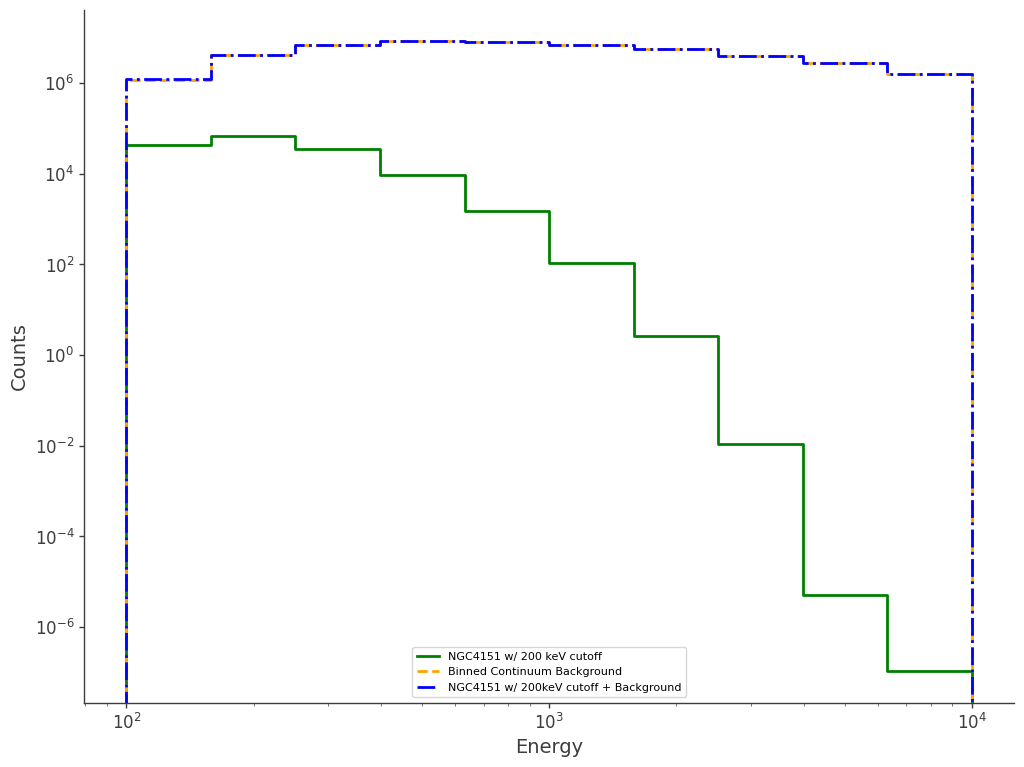

In [164]:
NGC4151_ec200 = Histogram.open("/Users/parshad/Software/AGN_Coronae/SourceInj/NGC_4151_ec200_COSI_sourceInj_correctFlux_hist.hdf5")
bkg = Histogram.open(data_path / "DC2/bkg_binned_data.hdf5")
NGC4151_ec200_bkg = Histogram.open("/Users/parshad/Software/AGN_Coronae/SourceInj/NGC_4151_ec200_bkg_hist.hdf5")

fig, ax = plt.subplots(figsize=(12, 9))
NGC4151_ec200.project("Em").draw(ax, label="NGC4151 w/ 200 keV cutoff", color="green")
bkg.project("Em").draw(ax, label="Binned Continuum Background", color="orange", linestyle="dashed")
NGC4151_ec200_bkg.project("Em").draw(ax, label="NGC4151 w/ 200keV cutoff + Background", linestyle='dashdot', color="blue")

ax.set_yscale("log")
ax.set_xscale("log")

# ax.set_ylim(1e0, 1e8)
ax.set_ylabel("Counts")
ax.set_xlabel("Energy")
plt.legend()

Define the path to the detector response

In [165]:
dr = str(data_path / "DC2/SMEXv12.Continuum.HEALPixO3_10bins_log_flat.binnedimaging.imagingresponse.nonsparse_nside8.area.good_chunks_unzip.h5") # path to detector response

## Perform spectral fit

Set background parameter, which is used to fit the amplitude of the background, and instantiate the COSI 3ML plugin

In [166]:
bkg_par = Parameter("background_cosi",                                         # background parameter
                     1,                                                        # initial value of parameter
                     min_value=0,                                              # minimum value of parameter
                     max_value=5,                                              # maximum value of parameter
                     delta=0.05,                                               # initial step used by fitting engine
                     desc="Background parameter for cosi")

cosi = COSILike("cosi",                                                        # COSI 3ML plugin
                 dr = dr,                                                      # detector response
                 data = NGC4151_ec200_bkg.project('Em', 'Phi', 'PsiChi'),   # data (source+background)
                 bkg = bkg.project('Em', 'Phi', 'PsiChi'),         # background model 
                 sc_orientation = sc_orientation,                              # spacecraft orientation
                 nuisance_param = bkg_par,                                     # background parameter
                 earth_occ = True)                                             # Option to account for Earth occultation

Define a point source at the known location with a Band function spectrum and add it to the model. The initial values of the Band function parameters are set to the true values used to simulate the source

In [142]:
l=155.07
b=75.06

# Give it some harsher initial guesses
K = 0.1 / u.cm / u.cm / u.s / u.keV
piv = 1. * u.keV
xc = 100. * u.keV
index = -1

spectrum = Cutoff_powerlaw()

spectrum.K.value = K.value
spectrum.piv.value = piv.value
spectrum.xc.value = xc.value
spectrum.index.value = index

# #Working parameters
# spectrum.K.min_value = 0.10
# spectrum.K.max_value = 0.17
# spectrum.xc.min_value = 180
# spectrum.xc.max_value = 210
# spectrum.index.min_value = -2.
# spectrum.index.max_value = -1.60

# Harsher Parameters
spectrum.K.min_value = 8e-2
spectrum.K.max_value = 2e-1
spectrum.xc.min_value = 100 # keep these relatively the same
spectrum.xc.max_value = 300
spectrum.index.min_value = -3 # change to -3.5 to sample lower, larger values (-5, 5)
spectrum.index.max_value = 1

spectrum.K.delta = 0.05
spectrum.xc.delta = 10
spectrum.index.delta = 0.25

spectrum.K.unit = K.unit
spectrum.piv.unit = piv.unit
spectrum.xc.unit = xc.unit

# fig, ax = plt.subplots()

# energy_grid = np.logspace(2, 4, 10000000)

# # ax.loglog(energy_grid, (energy_grid**2)*(spectrum(energy_grid)))
# ax.loglog(energy_grid, spectrum(energy_grid))
# ax.set_xlabel("energy [keV]")
# ax.set_ylim(1e-17, 1e-3)
# ax.set_ylabel(f"flux [{K.unit}]")

source = PointSource("source",                     # Name of source (arbitrary, but needs to be unique)
                     l = l,                        # Longitude (deg)
                     b = b,                        # Latitude (deg)
                     spectral_shape = spectrum)    # Spectral model

# # Optional: free the position parameters
# #source.position.l.free = True
# #source.position.b.free = True

model = Model(source)  # Model with single source. If we had multiple sources, we would do Model(source1, source2, ...)

# # Optional: if you want to call get_log_like manually, then you also need to set the model manually
# # 3ML does this internally during the fit though
cosi.set_model(model)

In [ ]:
l=155.07
b=75.06

# Give it some harsher initial guesses
K = 5 / u.cm / u.cm / u.s / u.keV
piv = 1. * u.keV
# xc = 1000. * u.keV
index = -2

spectrum = Powerlaw()

spectrum.K.value = K.value
spectrum.piv.value = piv.value
# spectrum.xc.value = xc.value
spectrum.index.value = index

# #Working parameters
# spectrum.K.min_value = 0.10
# spectrum.K.max_value = 0.17
# spectrum.xc.min_value = 180
# spectrum.xc.max_value = 210
# spectrum.index.min_value = -2.
# spectrum.index.max_value = -1.60

# # Harsher Parameters
spectrum.K.min_value = 1
spectrum.K.max_value = 12
# spectrum.xc.min_value = 800 # keep these relatively the same
# spectrum.xc.max_value = 1200
spectrum.index.min_value = -3.5 # change to -3.5 to sample lower, larger values (-5, 5)
spectrum.index.max_value = 1

spectrum.K.delta = 0.1
# # spectrum.xc.delta = 0.0001
spectrum.index.delta = 5e-1

spectrum.K.unit = K.unit
spectrum.piv.unit = piv.unit
# spectrum.xc.unit = xc.unit

# fig, ax = plt.subplots()

# energy_grid = np.logspace(2, 4, 10000000)

# # ax.loglog(energy_grid, (energy_grid**2)*(spectrum(energy_grid)))
# ax.loglog(energy_grid, spectrum(energy_grid))
# ax.set_xlabel("energy [keV]")
# ax.set_ylim(1e-17, 1e-3)
# ax.set_ylabel(f"flux [{K.unit}]")

source = PointSource("source",                     # Name of source (arbitrary, but needs to be unique)
                     l = l,                        # Longitude (deg)
                     b = b,                        # Latitude (deg)
                     spectral_shape = spectrum)    # Spectral model

# # Optional: free the position parameters
# #source.position.l.free = True
# #source.position.b.free = True

model = Model(source)  # Model with single source. If we had multiple sources, we would do Model(source1, source2, ...)

# # Optional: if you want to call get_log_like manually, then you also need to set the model manually
# # 3ML does this internally during the fit though
cosi.set_model(model)

Gather all plugins and combine with the model in a JointLikelihood object, then perform maximum likelihood fit

In [ ]:
plugins = DataList(cosi) # If we had multiple instruments, we would do e.g. DataList(cosi, lat, hawc, ...)

like = JointLikelihood(model, plugins, verbose = False)

like.fit() #increase number of samples?

10:16:39 WARNING   External parameter background_cosi already exist in the model. Overwriting it...    ]8;id=151455;file:///Users/parshad/.pyenv/versions/3.10.14/lib/python3.10/site-packages/astromodels/core/model.py\model.py]8;;\:]8;id=331333;file:///Users/parshad/.pyenv/versions/3.10.14/lib/python3.10/site-packages/astromodels/core/model.py#622\622]8;;\

10:16:39 INFO      set the minimizer to minuit                                             ]8;id=876202;file:///Users/parshad/.pyenv/versions/3.10.14/lib/python3.10/site-packages/threeML/classicMLE/joint_likelihood.py\joint_likelihood.py]8;;\:]8;id=942500;file:///Users/parshad/.pyenv/versions/3.10.14/lib/python3.10/site-packages/threeML/classicMLE/joint_likelihood.py#1045\1045]8;;\

Adding 1e-12 to each bin of the expectation to avoid log-likelihood = -inf.


10:17:02 WARNING   get_number_of_data_points not implemented, values for statistical        ]8;id=589087;file:///Users/parshad/.pyenv/versions/3.10.14/lib/python3.10/site-packages/threeML/plugin_prototype.py\plugin_prototype.py]8;;\:]8;id=269958;file:///Users/parshad/.pyenv/versions/3.10.14/lib/python3.10/site-packages/threeML/plugin_prototype.py#130\130]8;;\
                  measurements such as AIC or BIC are unreliable                                                   

         WARNING   31.6 percent of samples have been thrown away because they failed the   ]8;id=699376;file:///Users/parshad/.pyenv/versions/3.10.14/lib/python3.10/site-packages/threeML/analysis_results.py\analysis_results.py]8;;\:]8;id=324457;file:///Users/parshad/.pyenv/versions/3.10.14/lib/python3.10/site-packages/threeML/analysis_results.py#1740\1740]8;;\
                  constraints on the parameters. This results might not be suitable for                            
                  error propagation. Enlarge the boundaries until you loose less than 1                            
                  percent of the samples.                                                                          

...

Values of -log(likelihood) at the minimum:

,-log(likelihood)
cosi,-2.262965e+08
total,-2.262965e+08


Values of statistical measures:

,statistical measures
AIC,-4.525930e+08
BIC,-4.525930e+08


(                                         value  negative_error  \
 source.spectrum.main.Powerlaw.K      11.083357       -2.187827   
 source.spectrum.main.Powerlaw.index  -2.778280       -0.006158   
 background_cosi                       0.999684       -0.000185   
 
                                      positive_error     error             unit  
 source.spectrum.main.Powerlaw.K            0.367173  1.277500  1 / (keV s cm2)  
 source.spectrum.main.Powerlaw.index        0.043975  0.025066                   
 background_cosi                            0.000123  0.000154                   ,
        -log(likelihood)
 cosi      -2.262965e+08
 total     -2.262965e+08)

## Error propagation and plotting (Band function)

Define Band function spectrum injected into MEGAlib

In [130]:
K_inj = 0.15 / u.cm / u.cm / u.s / u.keV
piv_inj = 1. * u.keV
xc_inj = 200. * u.keV
index_inj = -1.75

spectrum_inj = Cutoff_powerlaw()

spectrum_inj.K.value = K_inj.value
spectrum_inj.piv.value = piv_inj.value
spectrum_inj.xc.value = xc_inj.value
spectrum_inj.index.value = index_inj

spectrum_inj.K.unit = K_inj.unit
spectrum_inj.piv.unit = piv_inj.unit
spectrum_inj.xc.unit = xc_inj.unit

The summary of the results above tell you the optimal values of the parameters, as well as the errors. Propogate the errors to the "evaluate_at" method of the spectrum

In [131]:
results = like.results

print(results.display())

parameters = {par.name:results.get_variates(par.path)
              for par in results.optimized_model["source"].parameters.values()
              if par.free}

results_err = results.propagate(results.optimized_model["source"].spectrum.main.shape.evaluate_at, **parameters)

print(results.optimized_model["source"])

Best fit values:

,result,unit
parameter,,
source.spectrum.main.Powerlaw.K,(1.11 -0.18 +0.22) x 10,1 / (keV s cm2)
source.spectrum.main.Powerlaw.index,-2.778 +/- 0.035,
background_cosi,(9.9968 +/- 0.0017) x 10^-1,


Correlation matrix:

1.00,-1.00,0.36
-1.00,1.00,-0.39
0.36,-0.39,1.00


Values of -log(likelihood) at the minimum:

,-log(likelihood)
cosi,-2.262965e+08
total,-2.262965e+08


Values of statistical measures:

,statistical measures
AIC,-4.525930e+08
BIC,-4.525930e+08


None
  * source (point source):
    * position:
      * l:
        * value: 155.07
        * desc: Galactic longitude
        * min_value: 0.0
        * max_value: 360.0
        * unit: deg
        * is_normalization: false
      * b:
        * value: 75.06
        * desc: Galactic latitude
        * min_value: -90.0
        * max_value: 90.0
        * unit: deg
        * is_normalization: false
      * equinox: J2000
    * spectrum:
      * main:
        * Powerlaw:
          * K:
            * value: 11.079665722853086
            * desc: Normalization (differential flux at the pivot value)
            * min_value: 1.0
            * max_value: 12.0
            * unit: keV-1 s-1 cm-2
            * is_normalization: true
          * piv:
            * value: 1.0
            * desc: Pivot value
            * min_value: null
            * max_value: null
            * unit: keV
            * is_normalization: false
          * index:
            * value: -2.778216435666289
            * 

Evaluate the flux and errors at a range of energies for the fitted and injected spectra, and the simulated source flux

In [132]:
energy = np.geomspace(100*u.keV,10*u.MeV).to_value(u.keV)

flux_lo = np.zeros_like(energy)
flux_median = np.zeros_like(energy)
flux_hi = np.zeros_like(energy)
flux_inj = np.zeros_like(energy)

for i, e in enumerate(energy):
    flux = results_err(e)
    flux_median[i] = flux.median
    flux_lo[i], flux_hi[i] = flux.equal_tail_interval(cl=0.68)
    flux_inj[i] = spectrum_inj.evaluate_at(e)
    
binned_energy_edges = NGC4151_ec200.axes['Em'].edges.value
# print(binned_energy_edges)
binned_energy = np.array([])
bin_sizes = np.array([])

for i in range(len(binned_energy_edges)-1):
    binned_energy = np.append(binned_energy, (binned_energy_edges[i+1] + binned_energy_edges[i]) / 2)
    bin_sizes = np.append(bin_sizes, binned_energy_edges[i+1] - binned_energy_edges[i])

expectation = cosi._expected_counts['source']

Plot the fitted and injected spectra

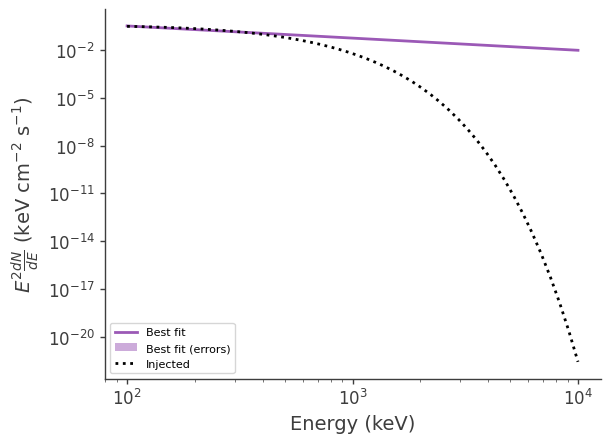

In [133]:
fig,ax = plt.subplots()

ax.plot(energy, energy*energy*flux_median, label = "Best fit")
ax.fill_between(energy, energy*energy*flux_lo, energy*energy*flux_hi, alpha = .5, label = "Best fit (errors)")
ax.plot(energy, energy*energy*flux_inj, color = 'black', ls = ":", label = "Injected")

ax.set_xscale("log")
ax.set_yscale("log")

ax.set_xlabel("Energy (keV)")
ax.set_ylabel(r"$E^2 \frac{dN}{dE}$ (keV cm$^{-2}$ s$^{-1}$)")

# ax.set_ylim(1e-3, 1)

ax.legend()

Plot the fitted spectrum convolved with the response, as well as the simulated source counts

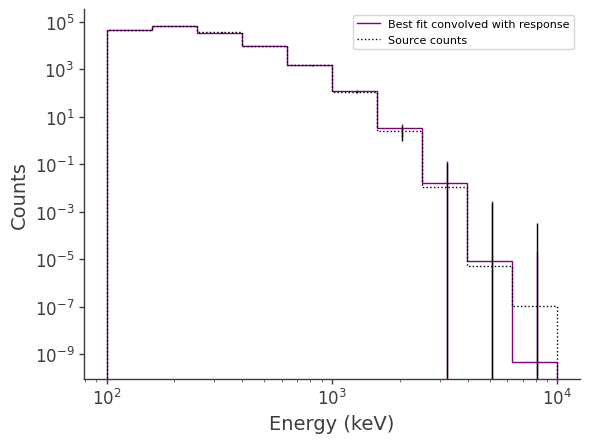

In [ ]:
fig,ax = plt.subplots()

ax.stairs(expectation.project('Em').todense().contents, binned_energy_edges, color='purple', label = "Best fit convolved with response")
ax.errorbar(binned_energy, expectation.project('Em').todense().contents, yerr=np.sqrt(expectation.project('Em').todense().contents), color='purple', linewidth=0, elinewidth=1)
ax.stairs(NGC4151_ec200.project('Em').todense().contents, binned_energy_edges, color = 'black', ls = ":", label = "Source counts")
ax.errorbar(binned_energy, NGC4151_ec200.project('Em').todense().contents, yerr=np.sqrt(NGC4151_ec200.project('Em').todense().contents), color='black', linewidth=0, elinewidth=1)

ax.set_xscale("log")
ax.set_yscale("log")

ax.set_xlabel("Energy (keV)")
ax.set_ylabel("Counts")

ax.legend()

Plot the fitted spectrum convolved with the response plus the fitted background, as well as the simulated source+background counts

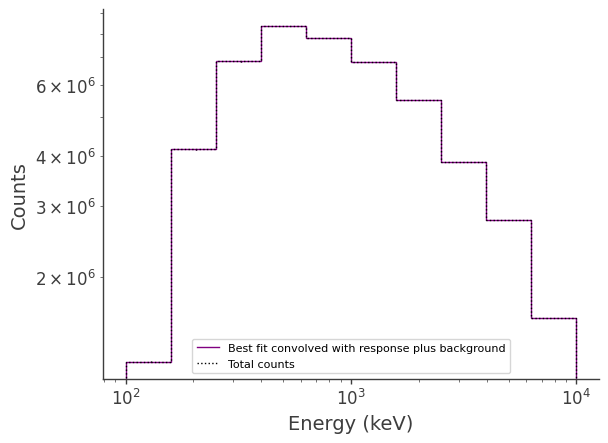

In [45]:
fig,ax = plt.subplots()

ax.stairs(expectation.project('Em').todense().contents+(bkg_par.value * bkg.project('Em').todense().contents), binned_energy_edges, color='purple', label = "Best fit convolved with response plus background")
ax.errorbar(binned_energy, expectation.project('Em').todense().contents+(bkg_par.value * bkg.project('Em').todense().contents), yerr=np.sqrt(expectation.project('Em').todense().contents+(bkg_par.value * bkg.project('Em').todense().contents)), color='purple', linewidth=0, elinewidth=1)
ax.stairs(NGC4151_ec200_bkg.project('Em').todense().contents, binned_energy_edges, color = 'black', ls = ":", label = "Total counts")
ax.errorbar(binned_energy, NGC4151_ec200_bkg.project('Em').todense().contents, yerr=np.sqrt(NGC4151_ec200_bkg.project('Em').todense().contents), color='black', linewidth=0, elinewidth=1)

ax.set_xscale("log")
ax.set_yscale("log")

ax.set_xlabel("Energy (keV)")
ax.set_ylabel("Counts")

ax.legend()

NGC 4151 with 1000 keV cutoff.

In [4]:
data_path = Path("/Users/parshad/Software/cosipyFiles")

In [ ]:
sc_orientation = SpacecraftFile.parse_from_file(data_path / "DC2/20280301_3_month_with_orbital_info.ori")

In [146]:
NGC4151_ec1000 = BinnedData(data_path / "NGC4151_ec1000.yaml")
NGC4151_ec1000_bkg = BinnedData(data_path / "NGC4151_ec1000.yaml")
bkg = BinnedData(data_path / "background.yaml")

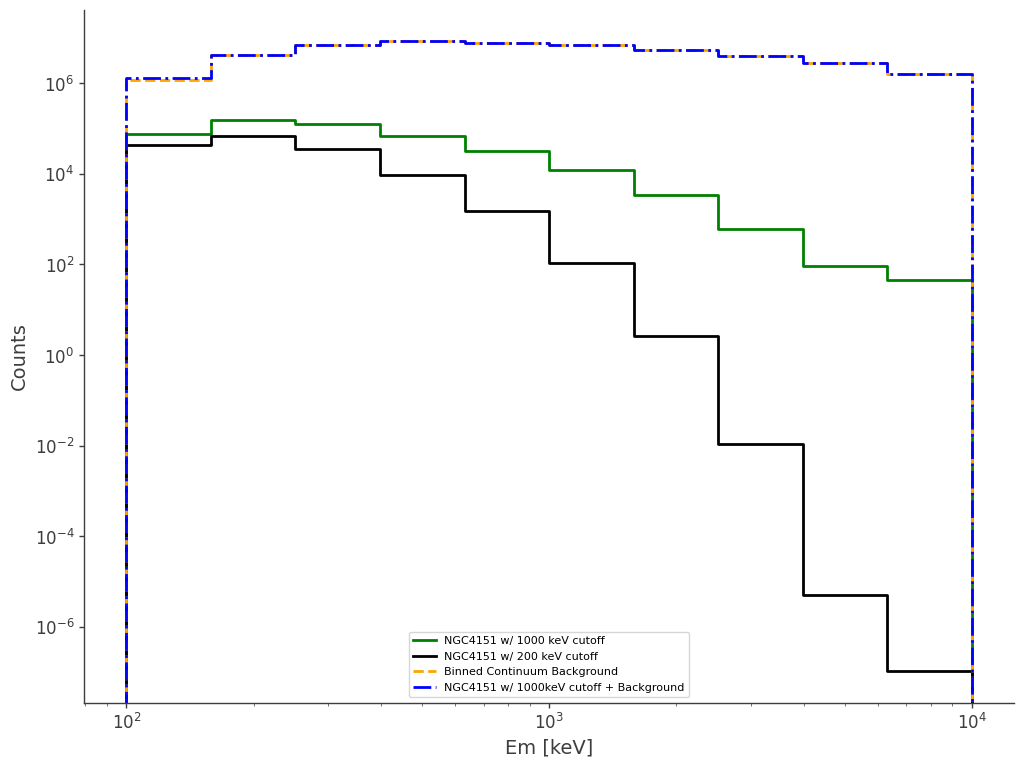

In [147]:
NGC4151_ec1000 = Histogram.open("/Users/parshad/Software/AGN_Coronae/SourceInj/NGC_4151_ec1000_COSI_sourceInj_correctFlux_hist.hdf5")
bkg = Histogram.open(data_path / "DC2/bkg_binned_data.hdf5")
NGC4151_ec1000_bkg = Histogram.open("/Users/parshad/Software/AGN_Coronae/SourceInj/NGC_4151_ec1000_bkg_hist.hdf5")
NGC4151_ec200 = Histogram.open("/Users/parshad/Software/AGN_Coronae/SourceInj/NGC_4151_ec200_COSI_sourceInj_correctFlux_hist.hdf5")

fig, ax = plt.subplots(figsize=(12, 9))
NGC4151_ec1000.project("Em").draw(ax, label="NGC4151 w/ 1000 keV cutoff", color="green")
NGC4151_ec200.project("Em").draw(ax, label="NGC4151 w/ 200 keV cutoff", color="black")
bkg.project("Em").draw(ax, label="Binned Continuum Background", color="orange", linestyle="dashed")
NGC4151_ec1000_bkg.project("Em").draw(ax, label="NGC4151 w/ 1000keV cutoff + Background", linestyle='dashdot', color="blue")

ax.set_yscale("log")
ax.set_xscale("log")

# ax.set_ylim(1e0, 1e8)
ax.set_ylabel("Counts")
plt.legend()

In [148]:
dr = str(data_path / "DC2/SMEXv12.Continuum.HEALPixO3_10bins_log_flat.binnedimaging.imagingresponse.nonsparse_nside8.area.good_chunks_unzip.h5") # path to detector response

In [149]:
bkg_par = Parameter("background_cosi",                                         # background parameter
                     1,                                                        # initial value of parameter
                     min_value=0,                                              # minimum value of parameter
                     max_value=5,                                              # maximum value of parameter
                     delta=0.05,                                               # initial step used by fitting engine
                     desc="Background parameter for cosi")

cosi = COSILike("cosi",                                                        # COSI 3ML plugin
                 dr = dr,                                                      # detector response
                 data = NGC4151_ec1000_bkg.project('Em', 'Phi', 'PsiChi'),   # data (source+background)
                 bkg = bkg.project('Em', 'Phi', 'PsiChi'),         # background model 
                 sc_orientation = sc_orientation,                              # spacecraft orientation
                 nuisance_param = bkg_par,                                     # background parameter
                 earth_occ = True)                                             # Option to account for Earth occultation

In [ ]:
l=155.07
b=75.06

# Give it some harsher initial guesses
K = 80 / u.cm / u.cm / u.s / u.keV
piv = 1. * u.keV
xc = 800. * u.keV
index = -0.75

spectrum = Cutoff_powerlaw()

spectrum.K.value = K.value
spectrum.piv.value = piv.value
spectrum.xc.value = xc.value
spectrum.index.value = index

# #Working parameters
# spectrum.K.min_value = 0.10
# spectrum.K.max_value = 0.17
# spectrum.xc.min_value = 180
# spectrum.xc.max_value = 210
# spectrum.index.min_value = -2.
# spectrum.index.max_value = -1.60

# # Harsher Parameters
spectrum.K.min_value = 75
spectrum.K.max_value = 2e2
spectrum.xc.min_value = 800 # keep these relatively the same
spectrum.xc.max_value = 1200
spectrum.index.min_value = -3 # change to -3.5 to sample lower, larger values (-5, 5)
spectrum.index.max_value = 1

spectrum.K.delta = 10
spectrum.xc.delta = 10
spectrum.index.delta = 0.1

spectrum.K.unit = K.unit
spectrum.piv.unit = piv.unit
spectrum.xc.unit = xc.unit

# fig, ax = plt.subplots()

# energy_grid = np.logspace(2, 4, 10000000)

# # ax.loglog(energy_grid, (energy_grid**2)*(spectrum(energy_grid)))
# ax.loglog(energy_grid, spectrum(energy_grid))
# ax.set_xlabel("energy [keV]")
# ax.set_ylim(1e-17, 1e-3)
# ax.set_ylabel(f"flux [{K.unit}]")

source = PointSource("source",                     # Name of source (arbitrary, but needs to be unique)
                     l = l,                        # Longitude (deg)
                     b = b,                        # Latitude (deg)
                     spectral_shape = spectrum)    # Spectral model

# # Optional: free the position parameters
# #source.position.l.free = True
# #source.position.b.free = True

model = Model(source)  # Model with single source. If we had multiple sources, we would do Model(source1, source2, ...)

# # Optional: if you want to call get_log_like manually, then you also need to set the model manually
# # 3ML does this internally during the fit though
cosi.set_model(model)

In [150]:
l=155.07
b=75.06

# Give it some harsher initial guesses
K = 1e-1 / u.cm / u.cm / u.s / u.keV
piv = 1. * u.keV
# xc = 1000. * u.keV
index = -1

spectrum = Powerlaw()

spectrum.K.value = K.value
spectrum.piv.value = piv.value
# spectrum.xc.value = xc.value
spectrum.index.value = index

# #Working parameters
# spectrum.K.min_value = 0.10
# spectrum.K.max_value = 0.17
# spectrum.xc.min_value = 180
# spectrum.xc.max_value = 210
# spectrum.index.min_value = -2.
# spectrum.index.max_value = -1.60

# # Harsher Parameters
spectrum.K.min_value = 1
spectrum.K.max_value = 12
# spectrum.xc.min_value = 800 # keep these relatively the same
# spectrum.xc.max_value = 1200
spectrum.index.min_value = -3.5 # change to -3.5 to sample lower, larger values (-5, 5)
spectrum.index.max_value = 2

spectrum.K.delta = 0.1
# # spectrum.xc.delta = 0.0001
spectrum.index.delta = 5e-1

spectrum.K.unit = K.unit
spectrum.piv.unit = piv.unit
# spectrum.xc.unit = xc.unit

# fig, ax = plt.subplots()

# energy_grid = np.logspace(2, 4, 10000000)

# # ax.loglog(energy_grid, (energy_grid**2)*(spectrum(energy_grid)))
# ax.loglog(energy_grid, spectrum(energy_grid))
# ax.set_xlabel("energy [keV]")
# ax.set_ylim(1e-17, 1e-3)
# ax.set_ylabel(f"flux [{K.unit}]")

source = PointSource("source",                     # Name of source (arbitrary, but needs to be unique)
                     l = l,                        # Longitude (deg)
                     b = b,                        # Latitude (deg)
                     spectral_shape = spectrum)    # Spectral model

# # Optional: free the position parameters
# #source.position.l.free = True
# #source.position.b.free = True

model = Model(source)  # Model with single source. If we had multiple sources, we would do Model(source1, source2, ...)

# # Optional: if you want to call get_log_like manually, then you also need to set the model manually
# # 3ML does this internally during the fit though
cosi.set_model(model)

10:06:40 WARNING   The current value of the parameter K (0.1) was below the new minimum 1.0.       ]8;id=191572;file:///Users/parshad/.pyenv/versions/3.10.14/lib/python3.10/site-packages/astromodels/core/parameter.py\parameter.py]8;;\:]8;id=573538;file:///Users/parshad/.pyenv/versions/3.10.14/lib/python3.10/site-packages/astromodels/core/parameter.py#720\720]8;;\

In [152]:
plugins = DataList(cosi) # If we had multiple instruments, we would do e.g. DataList(cosi, lat, hawc, ...)

like = JointLikelihood(model, plugins, verbose = False)

like.fit() #increase number of samples?

10:08:06 WARNING   External parameter background_cosi already exist in the model. Overwriting it...    ]8;id=973377;file:///Users/parshad/.pyenv/versions/3.10.14/lib/python3.10/site-packages/astromodels/core/model.py\model.py]8;;\:]8;id=342162;file:///Users/parshad/.pyenv/versions/3.10.14/lib/python3.10/site-packages/astromodels/core/model.py#622\622]8;;\

10:08:06 INFO      set the minimizer to minuit                                             ]8;id=505392;file:///Users/parshad/.pyenv/versions/3.10.14/lib/python3.10/site-packages/threeML/classicMLE/joint_likelihood.py\joint_likelihood.py]8;;\:]8;id=689720;file:///Users/parshad/.pyenv/versions/3.10.14/lib/python3.10/site-packages/threeML/classicMLE/joint_likelihood.py#1045\1045]8;;\

Adding 1e-12 to each bin of the expectation to avoid log-likelihood = -inf.


10:08:13 WARNING   get_number_of_data_points not implemented, values for statistical        ]8;id=598716;file:///Users/parshad/.pyenv/versions/3.10.14/lib/python3.10/site-packages/threeML/plugin_prototype.py\plugin_prototype.py]8;;\:]8;id=966258;file:///Users/parshad/.pyenv/versions/3.10.14/lib/python3.10/site-packages/threeML/plugin_prototype.py#130\130]8;;\
                  measurements such as AIC or BIC are unreliable                                                   

         WARNING   51.28 percent of samples have been thrown away because they failed the  ]8;id=484338;file:///Users/parshad/.pyenv/versions/3.10.14/lib/python3.10/site-packages/threeML/analysis_results.py\analysis_results.py]8;;\:]8;id=180333;file:///Users/parshad/.pyenv/versions/3.10.14/lib/python3.10/site-packages/threeML/analysis_results.py#1740\1740]8;;\
                  constraints on the parameters. This results might not be suitable for                            
                  error propagation. Enlarge the boundaries until you loose less than 1                            
                  percent of the samples.                                                                          

...

Values of -log(likelihood) at the minimum:

,-log(likelihood)
cosi,-2.280368e+08
total,-2.280368e+08


Values of statistical measures:

,statistical measures
AIC,-4.560736e+08
BIC,-4.560736e+08


(                                        value  negative_error  positive_error  \
 source.spectrum.main.Powerlaw.K      1.000000        0.000012        0.000084   
 source.spectrum.main.Powerlaw.index -2.175719        0.003700        0.025879   
 background_cosi                      1.000032       -0.000237        0.000079   
 
                                         error             unit  
 source.spectrum.main.Powerlaw.K      0.000048  1 / (keV s cm2)  
 source.spectrum.main.Powerlaw.index  0.014790                   
 background_cosi                      0.000158                   ,
        -log(likelihood)
 cosi      -2.280368e+08
 total     -2.280368e+08)

In [153]:
K_inj = 0.15 / u.cm / u.cm / u.s / u.keV
piv_inj = 1. * u.keV
xc_inj = 1000. * u.keV
index_inj = -1.75

spectrum_inj = Cutoff_powerlaw()

spectrum_inj.K.value = K_inj.value
spectrum_inj.piv.value = piv_inj.value
spectrum_inj.xc.value = xc_inj.value
spectrum_inj.index.value = index_inj

spectrum_inj.K.unit = K_inj.unit
spectrum_inj.piv.unit = piv_inj.unit
spectrum_inj.xc.unit = xc_inj.unit

In [154]:
results = like.results

print(results.display())

parameters = {par.name:results.get_variates(par.path)
              for par in results.optimized_model["source"].parameters.values()
              if par.free}

results_err = results.propagate(results.optimized_model["source"].spectrum.main.shape.evaluate_at, **parameters)

print(results.optimized_model["source"])

Best fit values:

,result,unit
parameter,,
source.spectrum.main.Powerlaw.K,1.00000 +/- 0.00006,1 / (keV s cm2)
source.spectrum.main.Powerlaw.index,-2.176 +/- 0.019,
background_cosi,1.00003 +/- 0.00018,


Correlation matrix:

1.00,1.00,-0.56
1.00,1.00,-0.58
-0.56,-0.58,1.00


Values of -log(likelihood) at the minimum:

,-log(likelihood)
cosi,-2.280368e+08
total,-2.280368e+08


Values of statistical measures:

,statistical measures
AIC,-4.560736e+08
BIC,-4.560736e+08


None
  * source (point source):
    * position:
      * l:
        * value: 155.07
        * desc: Galactic longitude
        * min_value: 0.0
        * max_value: 360.0
        * unit: deg
        * is_normalization: false
      * b:
        * value: 75.06
        * desc: Galactic latitude
        * min_value: -90.0
        * max_value: 90.0
        * unit: deg
        * is_normalization: false
      * equinox: J2000
    * spectrum:
      * main:
        * Powerlaw:
          * K:
            * value: 1.0000000167619825
            * desc: Normalization (differential flux at the pivot value)
            * min_value: 1.0
            * max_value: 12.0
            * unit: keV-1 s-1 cm-2
            * is_normalization: true
          * piv:
            * value: 1.0
            * desc: Pivot value
            * min_value: null
            * max_value: null
            * unit: keV
            * is_normalization: false
          * index:
            * value: -2.175718794306421
            * 

In [155]:
energy = np.geomspace(100*u.keV,10*u.MeV).to_value(u.keV)

flux_lo = np.zeros_like(energy)
flux_median = np.zeros_like(energy)
flux_hi = np.zeros_like(energy)
flux_inj = np.zeros_like(energy)

for i, e in enumerate(energy):
    flux = results_err(e)
    flux_median[i] = flux.median
    flux_lo[i], flux_hi[i] = flux.equal_tail_interval(cl=0.68)
    flux_inj[i] = spectrum_inj.evaluate_at(e)
    
binned_energy_edges = NGC4151_ec200.axes['Em'].edges.value
# print(binned_energy_edges)
binned_energy = np.array([])
bin_sizes = np.array([])

for i in range(len(binned_energy_edges)-1):
    binned_energy = np.append(binned_energy, (binned_energy_edges[i+1] + binned_energy_edges[i]) / 2)
    bin_sizes = np.append(bin_sizes, binned_energy_edges[i+1] - binned_energy_edges[i])

expectation = cosi._expected_counts['source']

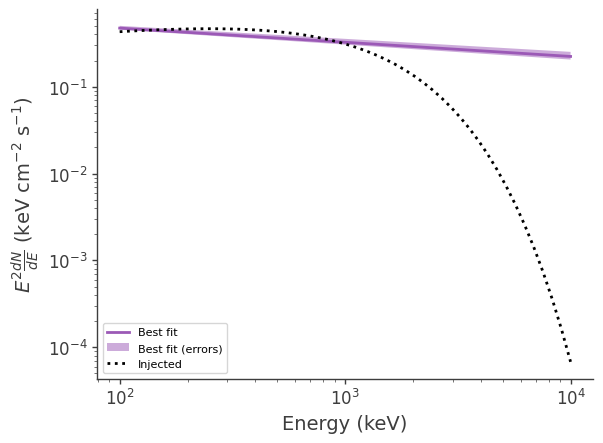

In [156]:
fig,ax = plt.subplots()

ax.plot(energy, energy*energy*flux_median, label = "Best fit")
ax.fill_between(energy, energy*energy*flux_lo, energy*energy*flux_hi, alpha = .5, label = "Best fit (errors)")
ax.plot(energy, energy*energy*flux_inj, color = 'black', ls = ":", label = "Injected")

ax.set_xscale("log")
ax.set_yscale("log")

ax.set_xlabel("Energy (keV)")
ax.set_ylabel(r"$E^2 \frac{dN}{dE}$ (keV cm$^{-2}$ s$^{-1}$)")

ax.legend()

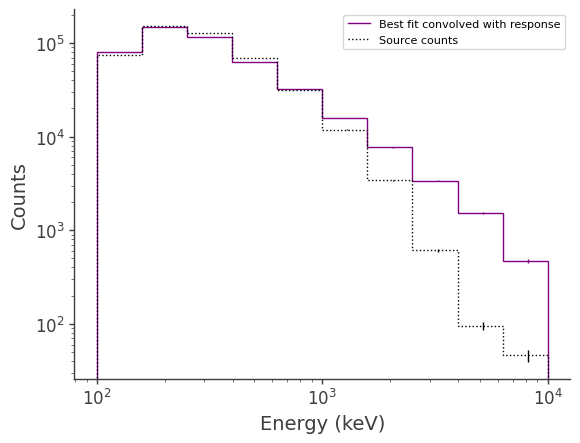

In [157]:
fig,ax = plt.subplots()

ax.stairs(expectation.project('Em').todense().contents, binned_energy_edges, color='purple', label = "Best fit convolved with response")
ax.errorbar(binned_energy, expectation.project('Em').todense().contents, yerr=np.sqrt(expectation.project('Em').todense().contents), color='purple', linewidth=0, elinewidth=1)
ax.stairs(NGC4151_ec1000.project('Em').todense().contents, binned_energy_edges, color = 'black', ls = ":", label = "Source counts")
ax.errorbar(binned_energy, NGC4151_ec1000.project('Em').todense().contents, yerr=np.sqrt(NGC4151_ec1000.project('Em').todense().contents), color='black', linewidth=0, elinewidth=1)

ax.set_xscale("log")
ax.set_yscale("log")

ax.set_xlabel("Energy (keV)")
ax.set_ylabel("Counts")

ax.legend()

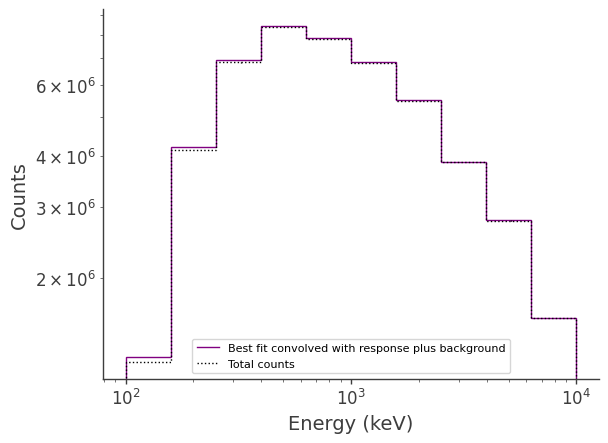

In [158]:
fig,ax = plt.subplots()

ax.stairs(expectation.project('Em').todense().contents+(bkg_par.value * bkg.project('Em').todense().contents), binned_energy_edges, color='purple', label = "Best fit convolved with response plus background")
ax.errorbar(binned_energy, expectation.project('Em').todense().contents+(bkg_par.value * bkg.project('Em').todense().contents), yerr=np.sqrt(expectation.project('Em').todense().contents+(bkg_par.value * bkg.project('Em').todense().contents)), color='purple', linewidth=0, elinewidth=1)
ax.stairs(NGC4151_ec200_bkg.project('Em').todense().contents, binned_energy_edges, color = 'black', ls = ":", label = "Total counts")
ax.errorbar(binned_energy, NGC4151_ec200_bkg.project('Em').todense().contents, yerr=np.sqrt(NGC4151_ec200_bkg.project('Em').todense().contents), color='black', linewidth=0, elinewidth=1)

ax.set_xscale("log")
ax.set_yscale("log")

ax.set_xlabel("Energy (keV)")
ax.set_ylabel("Counts")

ax.legend()

In [ ]:
data_path = Path("/Users/parshad/Software/cosipyFiles")

In [ ]:
sc_orientation = SpacecraftFile.parse_from_file(data_path / "20280301_3_month_with_orbital_info.ori")

In [ ]:
NGC4151_ec200 = BinnedData(data_path / "NGC4151_ec200.yaml")
NGC4151_ec200_bkg = BinnedData(data_path / "NGC4151_ec200.yaml")
bkg = BinnedData(data_path / "background.yaml")

Text(0, 0.5, 'Counts')

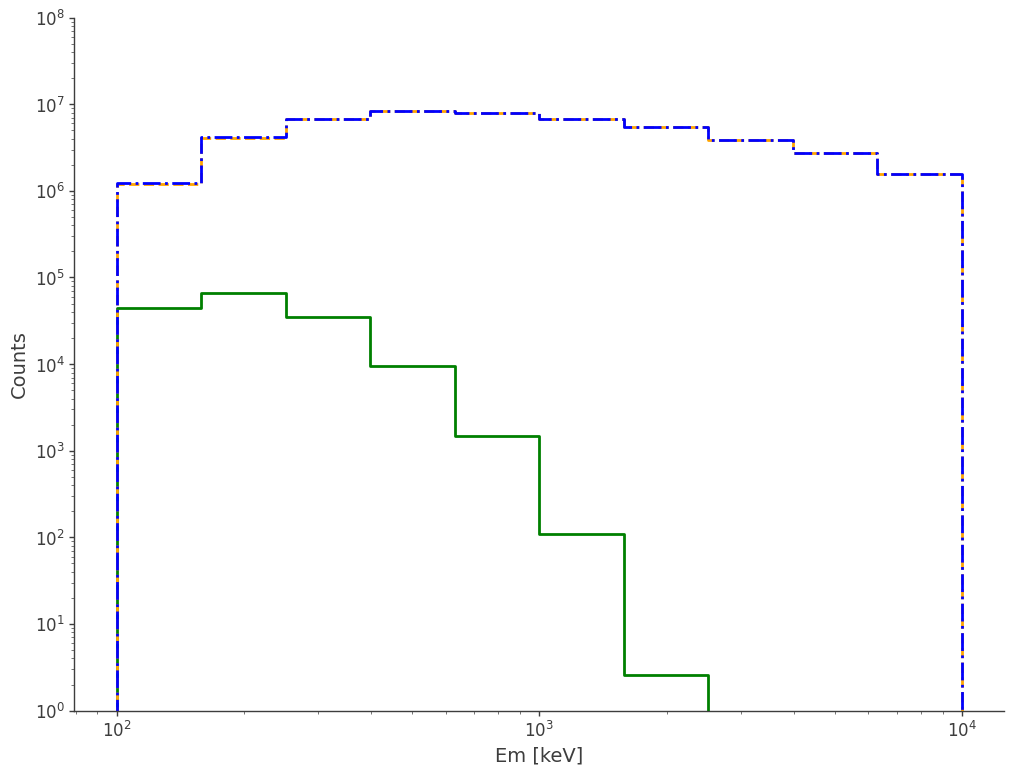

In [ ]:
NGC4151_ec200 = Histogram.open("/Users/parshad/Software/AGN_Coronae/SourceInj/NGC_4151_ec200_COSI_sourceInj_correctFlux_hist.hdf5")
bkg = Histogram.open(data_path / "bkg_binned_data.hdf5")
NGC4151_ec200_bkg = Histogram.open("/Users/parshad/Software/AGN_Coronae/SourceInj/NGC_4151_ec200_bkg_hist.hdf5")

fig, ax = plt.subplots(figsize=(12, 9))
NGC4151_ec200.project("Em").draw(ax, label="NGC4151 w/ 200 keV cutoff", color="green")
bkg.project("Em").draw(ax, label="Binned Continuum Background", color="orange", linestyle="dashed")
NGC4151_ec200_bkg.project("Em").draw(ax, label="NGC4151 w/ 200keV cutoff + Background", linestyle='dashdot', color="blue")

ax.set_yscale("log")
ax.set_xscale("log")

ax.set_ylim(1e0, 1e8)
ax.set_ylabel("Counts")

In [ ]:
dr = str(data_path / "SMEXv12.Continuum.HEALPixO3_10bins_log_flat.binnedimaging.imagingresponse.nonsparse_nside8.area.good_chunks_unzip.h5") # path to detector response

In [ ]:
bkg_par = Parameter("background_cosi",                                         # background parameter
                     1,                                                        # initial value of parameter
                     min_value=0,                                              # minimum value of parameter
                     max_value=5,                                              # maximum value of parameter
                     delta=0.05,                                               # initial step used by fitting engine
                     desc="Background parameter for cosi")

cosi = COSILike("cosi",                                                        # COSI 3ML plugin
                 dr = dr,                                                      # detector response
                 data = NGC4151_ec200_bkg.project('Em', 'Phi', 'PsiChi'),   # data (source+background)
                 bkg = bkg.project('Em', 'Phi', 'PsiChi'),         # background model 
                 sc_orientation = sc_orientation,                              # spacecraft orientation
                 nuisance_param = bkg_par,                                     # background parameter
                 earth_occ = True)                                             # Option to account for Earth occultation

In [ ]:
l=155.07
b=75.06

# Give it some harsher initial guesses
K = 0.15 / u.cm / u.cm / u.s / u.keV
piv = 1. * u.keV
xc = 200. * u.keV
index = -1.75

spectrum = Cutoff_powerlaw()

spectrum.K.value = K.value
spectrum.piv.value = piv.value
spectrum.xc.value = xc.value
spectrum.index.value = index

# #Working parameters
# spectrum.K.min_value = 0.10
# spectrum.K.max_value = 0.17
# spectrum.xc.min_value = 180
# spectrum.xc.max_value = 210
# spectrum.index.min_value = -2.
# spectrum.index.max_value = -1.60

# Harsher Parameters
spectrum.K.min_value = 0.05
spectrum.K.max_value = 0.22
spectrum.xc.min_value = 100 # keep these relatively the same
spectrum.xc.max_value = 300
spectrum.index.min_value = -2.5 # change to -3.5 to sample lower, larger values (-5, 5)
spectrum.index.max_value = -1.0

spectrum.K.delta = 0.01
spectrum.xc.delta = 0.01
spectrum.index.delta = 0.01

spectrum.K.unit = K.unit
spectrum.piv.unit = piv.unit
spectrum.xc.unit = xc.unit

# fig, ax = plt.subplots()

# energy_grid = np.logspace(2, 4, 10000000)

# # ax.loglog(energy_grid, (energy_grid**2)*(spectrum(energy_grid)))
# ax.loglog(energy_grid, spectrum(energy_grid))
# ax.set_xlabel("energy [keV]")
# ax.set_ylim(1e-17, 1e-3)
# ax.set_ylabel(f"flux [{K.unit}]")

source = PointSource("source",                     # Name of source (arbitrary, but needs to be unique)
                     l = l,                        # Longitude (deg)
                     b = b,                        # Latitude (deg)
                     spectral_shape = spectrum)    # Spectral model

# # Optional: free the position parameters
# #source.position.l.free = True
# #source.position.b.free = True

model = Model(source)  # Model with single source. If we had multiple sources, we would do Model(source1, source2, ...)

# # Optional: if you want to call get_log_like manually, then you also need to set the model manually
# # 3ML does this internally during the fit though
cosi.set_model(model)

In [ ]:
plugins = DataList(cosi) # If we had multiple instruments, we would do e.g. DataList(cosi, lat, hawc, ...)

like = JointLikelihood(model, plugins, verbose = False)

like.fit() #increase number of samples?

12:29:00 INFO      set the minimizer to minuit                                             ]8;id=227451;file:///Users/parshad/.pyenv/versions/3.10.14/lib/python3.10/site-packages/threeML/classicMLE/joint_likelihood.py\joint_likelihood.py]8;;\:]8;id=579863;file:///Users/parshad/.pyenv/versions/3.10.14/lib/python3.10/site-packages/threeML/classicMLE/joint_likelihood.py#1045\1045]8;;\

Adding 1e-12 to each bin of the expectation to avoid log-likelihood = -inf.


12:29:10 WARNING   get_number_of_data_points not implemented, values for statistical        ]8;id=657272;file:///Users/parshad/.pyenv/versions/3.10.14/lib/python3.10/site-packages/threeML/plugin_prototype.py\plugin_prototype.py]8;;\:]8;id=89461;file:///Users/parshad/.pyenv/versions/3.10.14/lib/python3.10/site-packages/threeML/plugin_prototype.py#130\130]8;;\
                  measurements such as AIC or BIC are unreliable                                                   

         WARNING   87.66000000000001 percent of samples have been thrown away because they ]8;id=104251;file:///Users/parshad/.pyenv/versions/3.10.14/lib/python3.10/site-packages/threeML/analysis_results.py\analysis_results.py]8;;\:]8;id=841862;file:///Users/parshad/.pyenv/versions/3.10.14/lib/python3.10/site-packages/threeML/analysis_results.py#1740\1740]8;;\
                  failed the constraints on the parameters. This results might not be                              
                  suitable for error propagation. Enlarge the boundaries until you loose                           
                  less than 1 percent of the samples.                                                              

12:29:10 WARNING   The current value of the parameter K (1.0) was above the new maximum 0.22.      ]8;id=991800;file:///Users/parshad/.pyenv/versions/3.10.14/lib/python3.10/site-packages/astromodels/core/parameter.py\parameter.py]8;;\:]8;id=4657;file:///Users/parshad/.pyenv/versions/3.10.14/lib/python3.10/site-packages/astromodels/core/parameter.py#794\794]8;;\

...

Values of -log(likelihood) at the minimum:

,-log(likelihood)
cosi,-6.774834e+12
total,-6.774834e+12


Values of statistical measures:

,statistical measures
AIC,-1.354967e+13
BIC,-1.354967e+13


(                                                 value  negative_error  \
 source.spectrum.main.Cutoff_powerlaw.K        0.220000   -2.753098e-11   
 source.spectrum.main.Cutoff_powerlaw.index   -1.000000   -1.053071e-10   
 source.spectrum.main.Cutoff_powerlaw.xc     300.000000   -3.576910e-07   
 background_cosi                               1.003169   -1.499204e-06   
 
                                             positive_error         error  \
 source.spectrum.main.Cutoff_powerlaw.K       -4.047040e-12  1.174197e-11   
 source.spectrum.main.Cutoff_powerlaw.index   -1.656941e-11  4.436884e-11   
 source.spectrum.main.Cutoff_powerlaw.xc      -6.319641e-08  1.472473e-07   
 background_cosi                               1.399522e-06  1.449363e-06   
 
                                                        unit  
 source.spectrum.main.Cutoff_powerlaw.K      1 / (keV s cm2)  
 source.spectrum.main.Cutoff_powerlaw.index                   
 source.spectrum.main.Cutoff_powerlaw.xc       

In [ ]:
K_inj = 0.15 / u.cm / u.cm / u.s / u.keV
piv_inj = 1. * u.keV
xc_inj = 200. * u.keV
index_inj = -1.75

spectrum_inj = Cutoff_powerlaw()

spectrum_inj.K.value = K_inj.value
spectrum_inj.piv.value = piv_inj.value
spectrum_inj.xc.value = xc_inj.value
spectrum_inj.index.value = index_inj

spectrum_inj.K.unit = K_inj.unit
spectrum_inj.piv.unit = piv_inj.unit
spectrum_inj.xc.unit = xc_inj.unit

In [ ]:
results = like.results

print(results.display())

parameters = {par.name:results.get_variates(par.path)
              for par in results.optimized_model["source"].parameters.values()
              if par.free}

results_err = results.propagate(results.optimized_model["source"].spectrum.main.shape.evaluate_at, **parameters)

print(results.optimized_model["source"])

Best fit values:

,result,unit
parameter,,
source.spectrum.main.Cutoff_powerlaw.K,(1.7000000 +/- 0.0000010) x 10^-1,1 / (keV s cm2)
source.spectrum.main.Cutoff_powerlaw.index,-1.600000000 +/- 0.000000010,
source.spectrum.main.Cutoff_powerlaw.xc,(2.1000000 +/- 0.0000015) x 10^2,keV
background_cosi,1.002985 +/- 0.000023,


Correlation matrix:

1.00,-0.00,0.00,0.00
-0.00,1.00,-0.00,-0.01
0.00,-0.00,1.00,0.00
0.00,-0.01,0.00,1.00


Values of -log(likelihood) at the minimum:

...

         WARNING   The current value of the parameter K (1.0) was above the new maximum 0.17.      ]8;id=371720;file:///Users/parshad/.pyenv/versions/3.10.14/lib/python3.10/site-packages/astromodels/core/parameter.py\parameter.py]8;;\:]8;id=701497;file:///Users/parshad/.pyenv/versions/3.10.14/lib/python3.10/site-packages/astromodels/core/parameter.py#794\794]8;;\

         WARNING   The current value of the parameter xc (10.0) was below the new minimum 180.0.   ]8;id=466758;file:///Users/parshad/.pyenv/versions/3.10.14/lib/python3.10/site-packages/astromodels/core/parameter.py\parameter.py]8;;\:]8;id=397707;file:///Users/parshad/.pyenv/versions/3.10.14/lib/python3.10/site-packages/astromodels/core/parameter.py#720\720]8;;\

         WARNING   The current value of the parameter K (1.0) was above the new maximum 0.17.      ]8;id=102563;file:///Users/parshad/.pyenv/versions/3.10.14/lib/python3.10/site-packages/astromodels/core/parameter.py\parameter.py]8;;\:]8;id=481659;file:///Users/parshad/.pyenv/versions/3.10.14/lib/python3.10/site-packages/astromodels/core/parameter.py#794\794]8;;\

         WARNING   The current value of the parameter xc (10.0) was below the new minimum 180.0.   ]8;id=796737;file:///Users/parshad/.pyenv/versions/3.10.14/lib/python3.10/site-packages/astromodels/core/parameter.py\parameter.py]8;;\:]8;id=261146;file:///Users/parshad/.pyenv/versions/3.10.14/lib/python3.10/site-packages/astromodels/core/parameter.py#720\720]8;;\

  * source (point source):
    * position:
      * l:
        * value: 155.07
        * desc: Galactic longitude
        * min_value: 0.0
        * max_value: 360.0
        * unit: deg
        * is_normalization: false
      * b:
        * value: 75.06
        * desc: Galactic latitude
        * min_value: -90.0
        * max_value: 90.0
        * unit: deg
        * is_normalization: false
      * equinox: J2000
    * spectrum:
      * main:
        * Cutoff_powerlaw:
          * K:
            * value: 0.16999999966129892
            * desc: Normalization (differential flux at the pivot value)
            * min_value: 0.1
            * max_value: 0.17
            * unit: keV-1 s-1 cm-2
            * is_normalization: true
          * piv:
            * value: 1.0
            * desc: Pivot value
            * min_value: null
            * max_value: null
            * unit: keV
            * is_normalization: false
          * index:
            * value: -1.6000000000033392
          

In [ ]:
energy = np.geomspace(100*u.keV,10*u.MeV).to_value(u.keV)

flux_lo = np.zeros_like(energy)
flux_median = np.zeros_like(energy)
flux_hi = np.zeros_like(energy)
flux_inj = np.zeros_like(energy)

for i, e in enumerate(energy):
    flux = results_err(e)
    flux_median[i] = flux.median
    flux_lo[i], flux_hi[i] = flux.equal_tail_interval(cl=0.68)
    flux_inj[i] = spectrum_inj.evaluate_at(e)
    
binned_energy_edges = NGC4151_ec200.axes['Em'].edges.value
# print(binned_energy_edges)
binned_energy = np.array([])
bin_sizes = np.array([])

for i in range(len(binned_energy_edges)-1):
    binned_energy = np.append(binned_energy, (binned_energy_edges[i+1] + binned_energy_edges[i]) / 2)
    bin_sizes = np.append(bin_sizes, binned_energy_edges[i+1] - binned_energy_edges[i])

expectation = cosi._expected_counts['source']

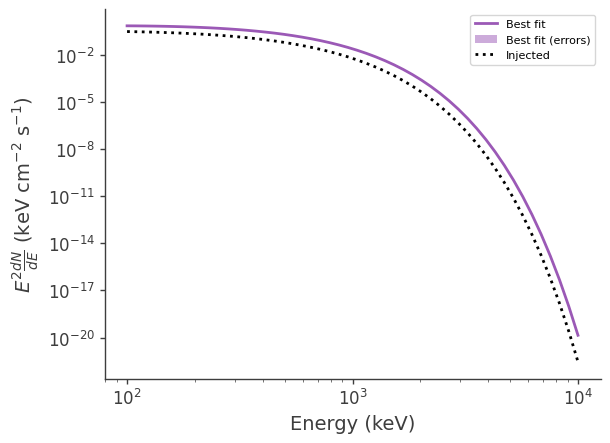

In [ ]:
fig,ax = plt.subplots()

ax.plot(energy, energy*energy*flux_median, label = "Best fit")
ax.fill_between(energy, energy*energy*flux_lo, energy*energy*flux_hi, alpha = .5, label = "Best fit (errors)")
ax.plot(energy, energy*energy*flux_inj, color = 'black', ls = ":", label = "Injected")

ax.set_xscale("log")
ax.set_yscale("log")

ax.set_xlabel("Energy (keV)")
ax.set_ylabel(r"$E^2 \frac{dN}{dE}$ (keV cm$^{-2}$ s$^{-1}$)")

ax.legend()

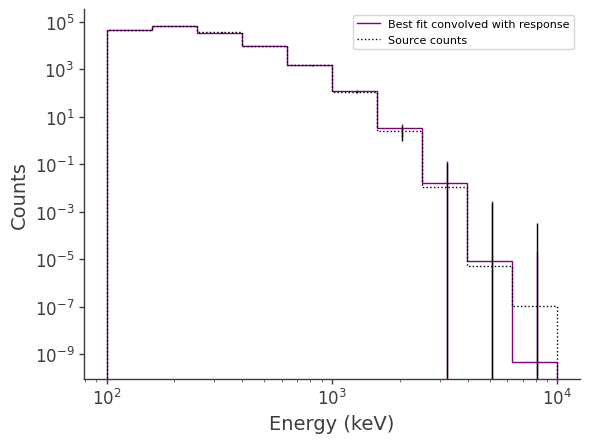

In [ ]:
fig,ax = plt.subplots()

ax.stairs(expectation.project('Em').todense().contents, binned_energy_edges, color='purple', label = "Best fit convolved with response")
ax.errorbar(binned_energy, expectation.project('Em').todense().contents, yerr=np.sqrt(expectation.project('Em').todense().contents), color='purple', linewidth=0, elinewidth=1)
ax.stairs(NGC4151_ec200.project('Em').todense().contents, binned_energy_edges, color = 'black', ls = ":", label = "Source counts")
ax.errorbar(binned_energy, NGC4151_ec200.project('Em').todense().contents, yerr=np.sqrt(NGC4151_ec200.project('Em').todense().contents), color='black', linewidth=0, elinewidth=1)

ax.set_xscale("log")
ax.set_yscale("log")

ax.set_xlabel("Energy (keV)")
ax.set_ylabel("Counts")

ax.legend()

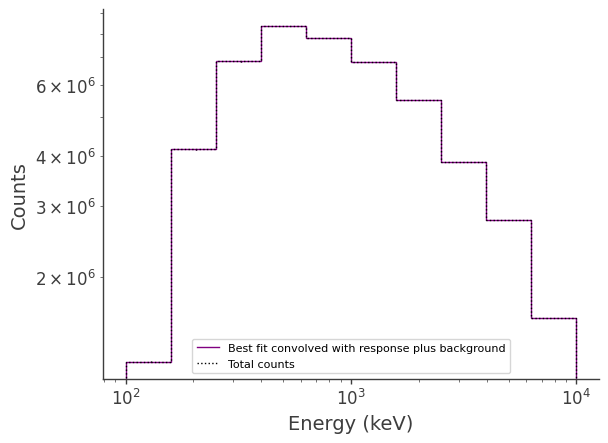

In [ ]:
fig,ax = plt.subplots()

ax.stairs(expectation.project('Em').todense().contents+(bkg_par.value * bkg.project('Em').todense().contents), binned_energy_edges, color='purple', label = "Best fit convolved with response plus background")
ax.errorbar(binned_energy, expectation.project('Em').todense().contents+(bkg_par.value * bkg.project('Em').todense().contents), yerr=np.sqrt(expectation.project('Em').todense().contents+(bkg_par.value * bkg.project('Em').todense().contents)), color='purple', linewidth=0, elinewidth=1)
ax.stairs(NGC4151_ec200_bkg.project('Em').todense().contents, binned_energy_edges, color = 'black', ls = ":", label = "Total counts")
ax.errorbar(binned_energy, NGC4151_ec200_bkg.project('Em').todense().contents, yerr=np.sqrt(NGC4151_ec200_bkg.project('Em').todense().contents), color='black', linewidth=0, elinewidth=1)

ax.set_xscale("log")
ax.set_yscale("log")

ax.set_xlabel("Energy (keV)")
ax.set_ylabel("Counts")

ax.legend()